# Analisis Data Transaksi
## Latar Belakang & Permasalahan

Kemudahan transaksi digital mendorong gaya hidup konsumtif, terutama di kalangan pengguna muda. Banyak pengguna kesulitan memantau keseimbangan antara pendapatan dan pengeluaran, serta tidak memiliki alat untuk mendeteksi transaksi yang tidak wajar.

## Permasalahan
Bagaimana menyediakan aplikasi yang dapat membantu pengguna memantau cashflow secara real-time, menganalisis pola pemasukan dan pengeluaran, serta memahami kondisi keuangan dengan lebih mudah dan terstruktur?

## Solusi
Membangun aplikasi manajemen cashflow yang memungkinkan pengguna memantau kondisi keuangan secara real-time, menganalisis pola pemasukan dan pengeluaran, serta memahami tren transaksi secara lebih terstruktur. Aplikasi dilengkapi dengan fitur filter dinamis, visualisasi data, dan analisis transaksi untuk membantu pengambilan keputusan finansial yang lebih efektif.

# Business Questions
Beberapa pertanyaan bisnis yang ingin dijawab dalam proyek ini:

1. Kategori pengeluaran apa yang paling dominan?
2. Merchant apa yang paling sering digunakan pengguna?
3. Bagaimana pola transaksi dari waktu ke waktu?
4. Apakah pengeluaran lebih besar dibanding pendapatan?
5. Metode pembayaran apa yang paling sering digunakan?
6. Bagaimana distribusi transaksi antar kota?
7. Apakah terdapat transaksi abnormal atau outlier?

# Import Library

In [274]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

plt.style.use('ggplot')

# Data Gathering

## Sumber Dataset

Dataset yang digunakan merupakan dataset sintetis transaksi finansial digital yang dibuat menggunakan Python.

Dataset mencakup beberapa kategori transaksi seperti:
- Makanan
- Transportasi
- Belanja
- Tagihan
- Hiburan
- Pendapatan

Dataset juga dibuat menyerupai kondisi nyata dengan menambahkan:
- duplicate data
- missing values
- typo merchant
- outlier realistis

In [275]:
## Load Dataset

In [276]:
df = pd.read_csv('../data/raw/dataset_fintech.csv')

## Preview Dataset

In [277]:
df.head()

,user_id,profil_user,tanggal,merchant,kategori,jumlah,jenis,metode_pembayaran,lokasi
0,USR008,Mahasiswa Hemat,2025-10-25,IndiHome,Tagihan,155525,Pengeluaran,QRIS,Semarang
1,USR072,Freelancer,2025-11-21,Telkomsel,Tagihan,67116,Pengeluaran,E-Wallet,Bandung
2,USR021,Pekerja Kantoran,2025-03-02,IndiHome,Tagihan,273844,Pengeluaran,Transfer,Semarang
3,USR065,Mahasiswa Boros,2025-07-22,Ayam Geprek,Makanan,20208,Pengeluaran,QRIS,Yogyakarta
4,USR010,Freelancer,2025-06-16,Uniqlo,Belanja,165598,Pengeluaran,Transfer,Semarang


# Assessing Data

## Cek Struktur Dataset

In [278]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 122391 entries, 0 to 122390
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   user_id            122391 non-null  object
 1   profil_user        122391 non-null  object
 2   tanggal            122391 non-null  object
 3   merchant           121779 non-null  object
 4   kategori           122391 non-null  object
 5   jumlah             122391 non-null  int64 
 6   jenis              122391 non-null  object
 7   metode_pembayaran  121779 non-null  object
 8   lokasi             122391 non-null  object
dtypes: int64(1), object(8)
memory usage: 8.4+ MB


Dataset memiliki **122.391 baris data** dan **9 kolom** yang berisi informasi terkait transaksi pengguna, kategori transaksi, merchant, metode pembayaran, serta lokasi transaksi.

- Dataset didominasi oleh tipe data kategorikal (`object`).
- Kolom `jumlah` merupakan satu-satunya variabel numerik yang merepresentasikan nominal transaksi pengguna.
- Terdapat missing value pada kolom `merchant` dan `metode_pembayaran`, namun jumlahnya relatif kecil dibanding total data.
- Kolom `tanggal` masih bertipe `object` sehingga perlu dikonversi ke format `datetime` sebelum dilakukan analisis berbasis waktu.
- Secara keseluruhan, struktur dataset sudah cukup baik untuk digunakan dalam analisis perilaku transaksi, segmentasi pengguna, maupun pengembangan model analisis finansial.

## Cek Statistik Deskriptif

In [279]:
df.describe()

,jumlah
count,1.223910e+05
mean,2.186579e+05
std,8.438046e+05
min,2.000000e+03
25%,2.474550e+04
50%,4.840100e+04
75%,1.115565e+05
max,1.399597e+07


Berdasarkan hasil statistik deskriptif pada kolom `jumlah`, terdapat sekitar **122 ribu transaksi** dengan rata-rata nominal transaksi sebesar **Rp218.658**.

- Nilai minimum transaksi tercatat sebesar **Rp2.000**, sedangkan nilai maksimum mencapai sekitar **Rp13,99 juta**.
- Median transaksi berada pada kisaran **Rp48.401**, yang menunjukkan bahwa sebagian besar transaksi bernilai relatif kecil.
- Perbedaan yang cukup besar antara nilai mean dan median mengindikasikan adanya transaksi bernilai tinggi yang memengaruhi distribusi data.
- Standar deviasi yang relatif tinggi menunjukkan bahwa variasi nominal transaksi antar pengguna cukup besar.
- Sebanyak 75% transaksi memiliki nilai di bawah **Rp111.556**, sehingga distribusi data cenderung **right-skewed** (miring ke kanan), yang umum ditemukan pada data finansial.

## Cek Missing Values

In [280]:
df.isnull().sum()

user_id                0
profil_user            0
tanggal                0
merchant             612
kategori               0
jumlah                 0
jenis                  0
metode_pembayaran    612
lokasi                 0
dtype: int64

Hasil pengecekan missing value menunjukkan bahwa sebagian besar kolom tidak memiliki data yang hilang.

- Kolom `merchant` memiliki **612 missing value**.
- Kolom `metode_pembayaran` juga memiliki **612 missing value**.
- Kolom lainnya tidak memiliki missing value sehingga kualitas data secara umum tergolong baik.

Jumlah missing value relatif kecil dibanding total data (sekitar **122 ribu baris**) sehingga tidak terlalu memengaruhi proses analisis. Missing value tersebut dapat ditangani melalui proses imputasi, penghapusan data, maupun pemberian label khusus sesuai kebutuhan analisis.

## Cek Duplicate Data

In [281]:
df.duplicated().sum()

np.int64(1183)

Hasil pengecekan menunjukkan terdapat **1.183 data duplikat** pada dataset.

Jumlah tersebut tergolong kecil dibanding total keseluruhan data, namun tetap perlu ditangani untuk menghindari bias dalam proses analisis maupun pemodelan.

Data duplikat dapat menyebabkan:
- perhitungan statistik menjadi kurang akurat,
- distribusi data menjadi bias,
- serta memengaruhi hasil analisis dan performa model machine learning.

Oleh karena itu, proses penghapusan data duplikat perlu dilakukan pada tahap preprocessing untuk menjaga kualitas data yang digunakan.

## Cek Unique Value Merchant

In [282]:
df['merchant'].unique()

array(['IndiHome', 'Telkomsel', 'Ayam Geprek', 'Uniqlo', 'Mixue',
       'Warteg Bahari', 'Fore Coffee', 'Indomrt', 'Blue Bird', 'MR DIY',
       'PLN', 'Gojek', 'BPJS', 'PDAM', 'KFC', 'Gaji Bulanan', 'THR',
       'Spotify', 'KRL', 'Mie Gacoan', 'Burger King', 'Tokped',
       'Alfamart', 'Lazada', 'Grab', 'Bakso Pak Kumis', 'Kopi Kenangan',
       'McD', 'Starbucks', 'SPBU Pertamina', 'Netflix', 'Steam',
       'Timezone', 'Shoppe', 'Chatime', 'ACE Hardware', 'XXI', nan,
       'Freelance', 'Bonus', 'Indomaret', "McDonald's", 'Shopee',
       'Tokopedia'], dtype=object)



Kolom `merchant` memiliki beragam jenis merchant yang mencerminkan aktivitas transaksi pengguna pada berbagai sektor, seperti:

- **Makanan & Minuman**: `Starbucks`, `Mixue`, `Mie Gacoan`, `KFC`, `McD`, `Chatime`
- **Transportasi**: `Grab`, `Gojek`, `Blue Bird`, `KRL`
- **E-Commerce**: `Tokopedia`, `Shopee`, `Lazada`
- **Tagihan & Utilitas**: `PLN`, `PDAM`, `BPJS`, `Telkomsel`, `IndiHome`
- **Hiburan**: `Netflix`, `Spotify`, `Steam`, `XXI`, `Timezone`
- **Pendapatan**: `Gaji Bulanan`, `THR`, `Bonus`, `Freelance`

Ditemukan juga beberapa inkonsistensi penulisan data, seperti:
- `McD` dan `McDonald's`
- `Shoppe` dan `Shopee`
- `Tokped` dan `Tokopedia`
- `Indomrt` dan `Indomaret`

Inkonsistensi tersebut menunjukkan perlunya proses **data cleaning** dan standardisasi nama merchant agar hasil analisis menjadi lebih akurat.

## Cek Outlier Nominal

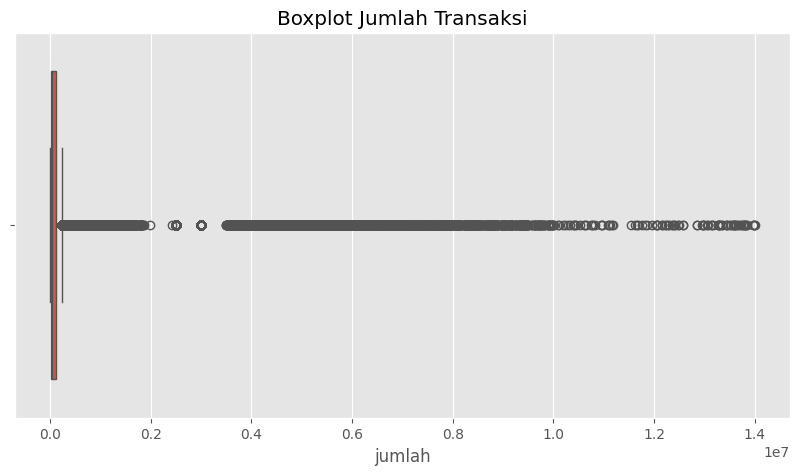

In [283]:
plt.figure(figsize=(10,5))

sns.boxplot(x=df['jumlah'])

plt.title('Boxplot Jumlah Transaksi')
plt.show()


Berdasarkan visualisasi boxplot pada kolom `jumlah`, terlihat terdapat cukup banyak outlier pada data transaksi. Sebagian besar transaksi berada pada nominal yang relatif rendah, namun terdapat beberapa transaksi dengan nilai sangat tinggi hingga mencapai lebih dari **Rp13 juta**.

Hal ini menunjukkan bahwa distribusi data cenderung **right-skewed** (miring ke kanan), sehingga nilai rata-rata transaksi dapat dipengaruhi oleh transaksi bernilai ekstrem. Oleh karena itu, penanganan outlier perlu dipertimbangkan sebelum dilakukan analisis lanjutan maupun proses pemodelan data.

# Cleaning Data
Tahap cleaning data dilakukan untuk meningkatkan kualitas dataset sebelum proses analisis lebih lanjut. Proses ini meliputi penghapusan data duplikat, penanganan missing value, serta perbaikan inkonsistensi penulisan data.

## Hapus Duplicate
Penghapusan data duplikat dilakukan untuk menghindari perhitungan ganda yang dapat memengaruhi hasil analisis.

In [284]:
df = df.drop_duplicates()

## Handle Missing Value
Pada tahap ini, missing value pada kolom `merchant` dan `metode_pembayaran` ditangani menggunakan metode imputasi dengan mengganti nilai kosong menjadi `"Unknown"`. 
Metode ini dipilih agar data tetap dipertahankan dan tidak mengurangi jumlah observasi pada dataset.

In [285]:
df['merchant'] = df['merchant'].fillna('Unknown')
df['metode_pembayaran'] = df['metode_pembayaran'].fillna('Unknown')

- Missing value berhasil ditangani tanpa menghapus data transaksi.
- Penggunaan label "Unknown" membantu mempertahankan jumlah data tetap utuh.
- Dataset menjadi lebih siap digunakan untuk proses analisis dan visualisasi.

## Perbaiki Typo Merchant
Perbaikan typo dilakukan untuk menyamakan penulisan nama merchant yang tidak konsisten.

In [286]:
replace_merchant = {
    'Tokped': 'Tokopedia',
    'Shoppe': 'Shopee',
    'McD': "McDonald's",
    'Indomrt': 'Indomaret'
}

df['merchant'] = df['merchant'].replace(replace_merchant)

- Inkonsistensi penulisan merchant berhasil diperbaiki.
- Standardisasi nama merchant membantu menghasilkan analisis yang lebih akurat.
- Visualisasi data menjadi lebih rapi dan tidak terpecah akibat typo.

## Konversi Tanggal
Pada tahap ini dilakukan konversi tipe data pada kolom `tanggal` dari tipe `object` menjadi tipe `datetime`.

Konversi ini diperlukan agar data tanggal dapat digunakan untuk analisis berbasis waktu, seperti analisis harian, bulanan, maupun tren transaksi.

In [287]:
df['tanggal'] = pd.to_datetime(df['tanggal'])

## Cek Tipe Data
Pengecekan tipe data dilakukan kembali setelah proses cleaning dan konversi data untuk memastikan setiap kolom memiliki tipe data yang sesuai.

In [288]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 121208 entries, 0 to 122389
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   user_id            121208 non-null  object        
 1   profil_user        121208 non-null  object        
 2   tanggal            121208 non-null  datetime64[ns]
 3   merchant           121208 non-null  object        
 4   kategori           121208 non-null  object        
 5   jumlah             121208 non-null  int64         
 6   jenis              121208 non-null  object        
 7   metode_pembayaran  121208 non-null  object        
 8   lokasi             121208 non-null  object        
dtypes: datetime64[ns](1), int64(1), object(7)
memory usage: 9.2+ MB


Setelah proses data cleaning dilakukan, jumlah data menjadi **121.208 baris** dari sebelumnya **122.391 baris**, yang menunjukkan bahwa data duplikat telah berhasil dihapus.

- Missing value pada kolom `merchant` dan `metode_pembayaran` telah ditangani sehingga seluruh kolom kini tidak memiliki nilai kosong.
- Kolom `tanggal` telah berhasil dikonversi ke tipe data `datetime` sehingga dapat digunakan untuk analisis berbasis waktu.
- Struktur dataset setelah preprocessing menjadi lebih bersih, konsisten, dan siap digunakan untuk tahap eksplorasi data maupun analisis lebih lanjut.

# Exploratory Data Analysis (EDA)

# Pertanyaan Bisnis 1
## Kategori Pengeluaran Apa yang Paling Dominan?

In [289]:
expense_df = df[df['jenis'] == 'Pengeluaran']

kategori_expense = expense_df.groupby('kategori')['jumlah'].sum().sort_values(ascending=False)

kategori_expense

kategori
Tagihan         4465979222
Belanja         4420997550
Makanan         1757661248
Transportasi    1296267629
Hiburan          877306758
Name: jumlah, dtype: int64

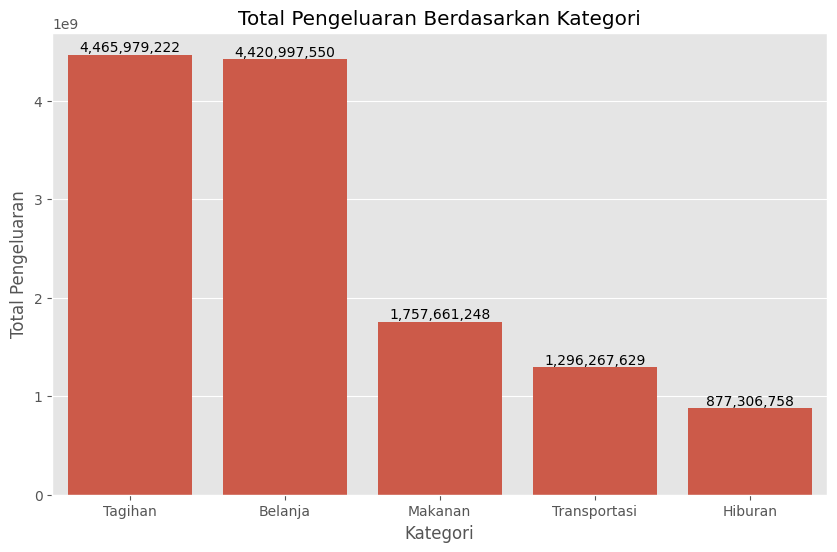

In [290]:
plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=kategori_expense.index,
    y=kategori_expense.values
)

# kasih label angka
for i, value in enumerate(kategori_expense.values):
    ax.text(
        i,
        value,
        f'{value:,.0f}',
        ha='center',
        va='bottom'
    )

plt.title('Total Pengeluaran Berdasarkan Kategori')
plt.xlabel('Kategori')
plt.ylabel('Total Pengeluaran')

plt.show()

Kategori **Belanja** menjadi kategori transaksi dengan nominal tertinggi dibanding kategori lainnya. Hal ini menunjukkan bahwa aktivitas transaksi pengguna didominasi oleh kebutuhan konsumtif, khususnya pada transaksi retail dan pembelian harian.

Selain itu, tingginya pengeluaran pada kategori **Tagihan** menunjukkan bahwa kebutuhan rutin seperti listrik, internet, dan layanan berlangganan memiliki kontribusi besar terhadap cash flow pengguna setiap bulan.


# Pertanyaan Bisnis 2
## Merchant Apa yang Paling Sering Digunakan?

In [291]:
top_merchant = df['merchant'].value_counts().head(10)

top_merchant

merchant
Grab              4800
Indomaret         4762
Blue Bird         4748
Gojek             4725
KRL               4649
PLN               4630
MR DIY            4623
SPBU Pertamina    4618
Alfamart          4537
IndiHome          4529
Name: count, dtype: int64

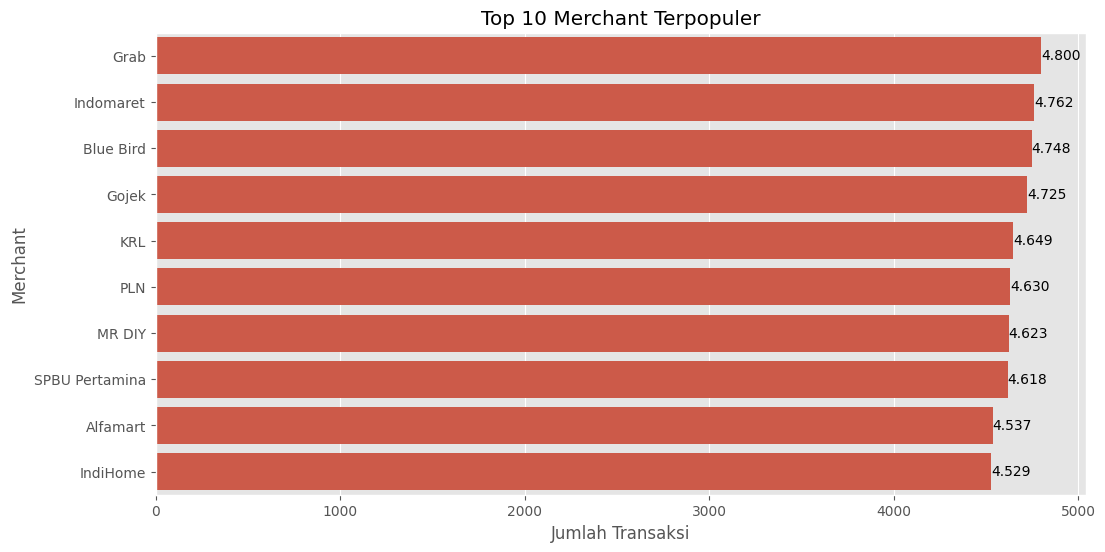

In [292]:
plt.figure(figsize=(12,6))

ax = sns.barplot(
    x=top_merchant.values,
    y=top_merchant.index
)

# tambah angka
for i, value in enumerate(top_merchant.values):
    ax.text(
        value,
        i,
        f'{value:,}'.replace(',', '.'),
        va='center'
    )

plt.title('Top 10 Merchant Terpopuler')
plt.xlabel('Jumlah Transaksi')
plt.ylabel('Merchant')

plt.show()



Merchant dengan frekuensi transaksi tertinggi menunjukkan adanya konsentrasi aktivitas pengguna pada merchant tertentu, terutama pada sektor transportasi, retail, dan layanan utilitas. Tingginya penggunaan merchant seperti **Grab**, **Gojek**, **Indomaret**, dan **Blue Bird** menunjukkan bahwa kebutuhan mobilitas dan belanja harian menjadi aktivitas transaksi yang paling dominan dilakukan pengguna.

Selain itu, munculnya merchant utilitas seperti **PLN** dan **IndiHome** menunjukkan bahwa pembayaran kebutuhan rutin juga memiliki kontribusi besar dalam aktivitas finansial pengguna.

# Pertanyaan Bisnis 3
## Bagaimana Pola Transaksi dari Waktu ke Waktu?

In [293]:
transaksi_harian = df.groupby('tanggal')['jumlah'].sum().reset_index()

transaksi_harian.head()

,tanggal,jumlah
0,2025-01-01,618950748
1,2025-01-02,79976079
2,2025-01-03,30052167
3,2025-01-04,32411242
4,2025-01-05,73642600


In [294]:
trend_df = (
    df
    .groupby(["tanggal", "jenis"])["jumlah"]
    .sum()
    .reset_index()
)

fig = px.line(
    trend_df,
    x="tanggal",
    y="jumlah",
    color="jenis",
    title="Tren Pendapatan dan Pengeluaran Pengguna",
    markers=True,
    color_discrete_map={
        "Pendapatan": "green",
        "Pengeluaran": "red"
    }
)

fig.update_layout(
    xaxis_title="Tanggal",
    yaxis_title="Nominal (Rp)",
    legend_title="Jenis Transaksi"
)

fig.show()

Fluktuasi transaksi harian menunjukkan bahwa aktivitas finansial pengguna dipengaruhi oleh waktu-waktu tertentu, seperti awal bulan, periode gajian, pembayaran tagihan rutin, maupun promo belanja. Meskipun sebagian besar transaksi berada pada kondisi yang relatif stabil, terdapat beberapa lonjakan transaksi yang cukup tinggi pada periode tertentu.


# Pertanyaan Bisnis 4
## Perbandingan Pendapatan dan Pengeluaran

In [295]:
cashflow = df.groupby('jenis')['jumlah'].sum()

cashflow

jenis
Pendapatan     13622838915
Pengeluaran    12818212407
Name: jumlah, dtype: int64

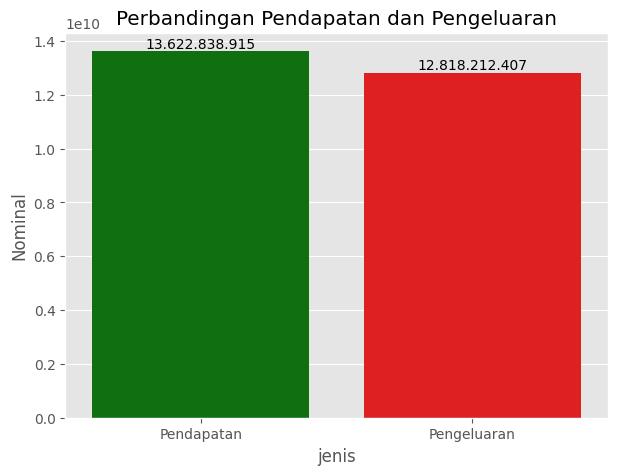

In [296]:
plt.figure(figsize=(7,5))

color_map = {
    'Pendapatan': 'green',
    'Pengeluaran': 'red'
}

ax = sns.barplot(
    x=cashflow.index,
    y=cashflow.values,
    hue=cashflow.index,         
    palette=color_map,
    legend=False                  
)

for i, value in enumerate(cashflow.values):
    ax.text(
        i,
        value,
        f'{value:,.0f}'.replace(',', '.'),
        ha='center',
        va='bottom'
    )

plt.title('Perbandingan Pendapatan dan Pengeluaran')
plt.ylabel('Nominal')
plt.show()

Perbandingan antara total pendapatan dan pengeluaran menunjukkan bahwa secara keseluruhan kondisi cash flow pengguna masih tergolong positif, meskipun selisihnya tidak terlalu besar. Hal ini mengindikasikan bahwa sebagian pengguna masih memiliki kemampuan untuk menyisihkan dana setelah memenuhi kebutuhan transaksi mereka.

Namun, selisih yang relatif tipis antara pendapatan dan pengeluaran juga menunjukkan adanya potensi risiko pengeluaran berlebih apabila pengguna tidak mengelola keuangan dengan baik.

### Analisis Lanjutan Pertanyaan 4: Perbandingan Pendapatan vs Pengeluaran per Profil Pengguna, Kota, dan User

Perbandingan Pendapatan vs Pengeluaran per Profil Pengguna:
jenis             Pendapatan  Pengeluaran     selisih
profil_user                                          
Pekerja Kantoran  2199597497   1005539124  1194058373
Freelancer        3318427682   2414729238   903698444
Mahasiswa Hemat   1399079693    850034850   549044843
Coffee Addict     2282300390   2246971026    35329364
Gamer             2418275913   2880261761  -461985848
Mahasiswa Boros   2005157740   3420676408 -1415518668


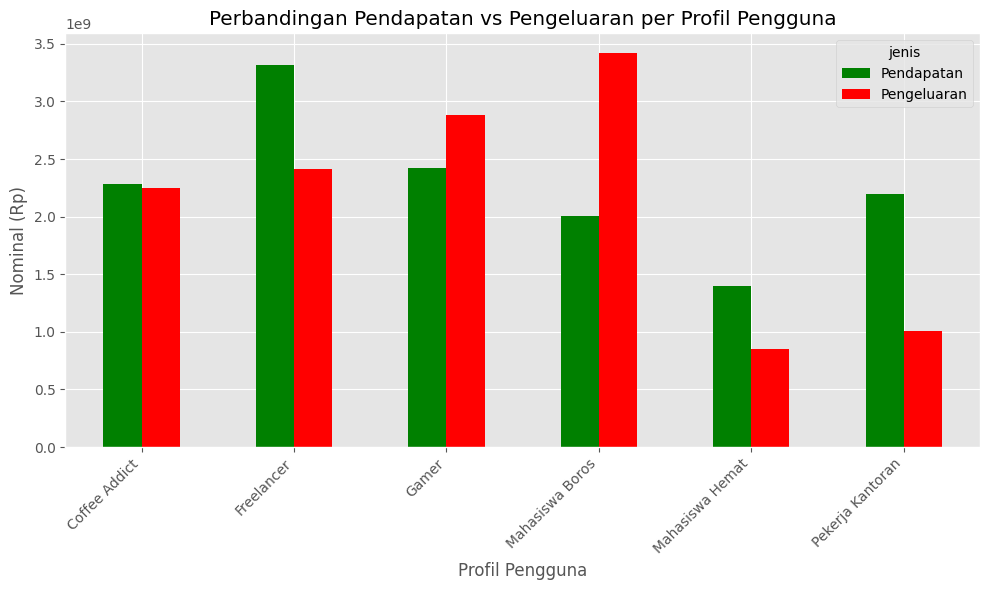

In [297]:
# Analisis perbandingan pendapatan vs pengeluaran per profil pengguna
cashflow_by_profile = df.groupby(['profil_user', 'jenis'])['jumlah'].sum().unstack()

# Hitung selisih (pendapatan - pengeluaran) dan urutkan
cashflow_by_profile['selisih'] = cashflow_by_profile.get('Pendapatan', 0) - cashflow_by_profile.get('Pengeluaran', 0)
cashflow_by_profile_sorted = cashflow_by_profile.sort_values('selisih', ascending=False)

print("Perbandingan Pendapatan vs Pengeluaran per Profil Pengguna:")
print(cashflow_by_profile_sorted)

# Visualisasi
fig, ax = plt.subplots(figsize=(10,6))
cashflow_by_profile[['Pendapatan', 'Pengeluaran']].plot(kind='bar', ax=ax, color=['green', 'red'])
ax.set_title('Perbandingan Pendapatan vs Pengeluaran per Profil Pengguna')
ax.set_ylabel('Nominal (Rp)')
ax.set_xlabel('Profil Pengguna')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()



Berdasarkan hasil analisis cash flow, profil **Pekerja Kantoran** memiliki surplus tertinggi sekitar **Rp1,19 miliar**, diikuti oleh **Freelancer** dengan surplus sekitar **Rp903 juta**. Profil **Mahasiswa Hemat** juga menunjukkan cash flow positif dengan surplus sekitar **Rp549 juta**.

Sementara itu, profil **Coffee Addict** memiliki selisih pendapatan dan pengeluaran yang relatif kecil sehingga kondisi cash flow cenderung seimbang.

Di sisi lain, profil **Gamer** dan **Mahasiswa Boros** mengalami defisit, dengan defisit terbesar terdapat pada profil **Mahasiswa Boros** yang mencapai sekitar **Rp1,41 miliar**.

Hasil ini menunjukkan bahwa terdapat perbedaan pola pengeluaran dan keseimbangan cash flow pada masing-masing profil pengguna.


Perbandingan Pendapatan vs Pengeluaran per Kota:
jenis       Pendapatan  Pengeluaran    selisih
lokasi                                        
Jakarta     2549936015   2095420095  454515920
Semarang    2283439757   1987097212  296342545
Bandung     3018123619   2917368945  100754674
Yogyakarta  2522489644   2538983869  -16494225
Surabaya    3248849880   3279342286  -30492406


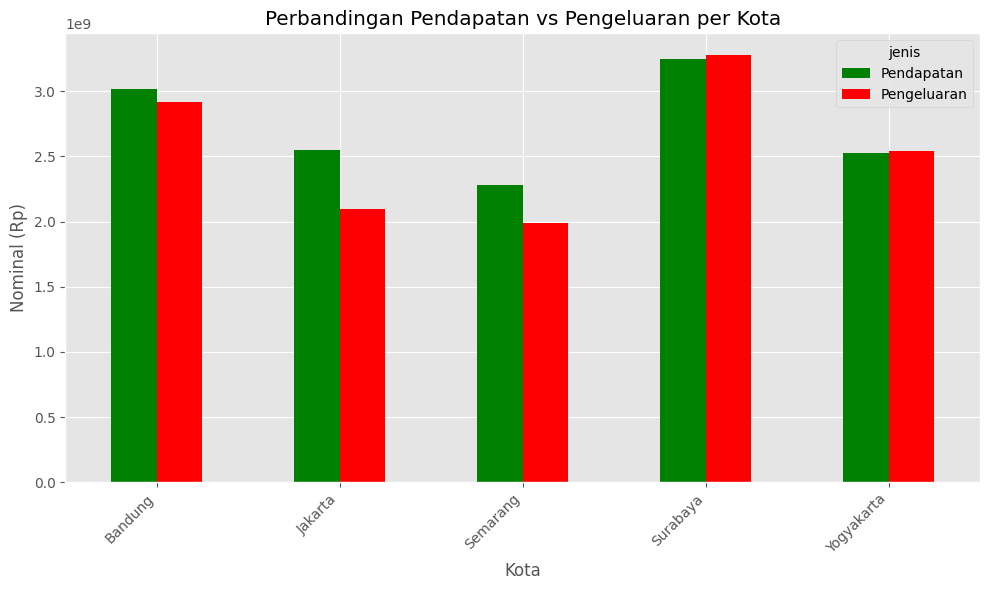

In [298]:
# Analisis perbandingan per kota
cashflow_by_city = df.groupby(['lokasi', 'jenis'])['jumlah'].sum().unstack()
cashflow_by_city['selisih'] = cashflow_by_city.get('Pendapatan', 0) - cashflow_by_city.get('Pengeluaran', 0)
cashflow_by_city_sorted = cashflow_by_city.sort_values('selisih', ascending=False)

print("\nPerbandingan Pendapatan vs Pengeluaran per Kota:")
print(cashflow_by_city_sorted)

# Visualisasi per kota
fig, ax = plt.subplots(figsize=(10,6))
cashflow_by_city[['Pendapatan', 'Pengeluaran']].plot(kind='bar', ax=ax, color=['green', 'red'])
ax.set_title('Perbandingan Pendapatan vs Pengeluaran per Kota')
ax.set_ylabel('Nominal (Rp)')
ax.set_xlabel('Kota')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Berdasarkan hasil analisis cash flow per kota, **Jakarta** memiliki surplus tertinggi sekitar **Rp454 juta**, diikuti oleh **Semarang** dengan surplus sekitar **Rp296 juta**. Kota **Bandung** juga menunjukkan cash flow positif dengan surplus sekitar **Rp100 juta**.

Sementara itu, **Yogyakarta** dan **Surabaya** mengalami defisit, dengan total pengeluaran yang sedikit lebih tinggi dibanding pendapatan.

Hasil ini menunjukkan adanya perbedaan kondisi cash flow antar kota, baik dari sisi tingkat pendapatan maupun pola pengeluaran pengguna.

Perbandingan Pendapatan vs Pengeluaran per User:
jenis    Pendapatan  Pengeluaran    selisih
user_id                                    
USR143    171991840     67189054  104802786
USR092    167148456     65832501  101315955
USR012    166456806     65918954  100537852
USR141    152970144     61595341   91374803
USR080    145780460     59552168   86228292
USR071    138533484     60733315   77800169
USR054    138865346     62104480   76760866
USR059    142654517     65964099   76690418
USR073    134814109     58742133   76071976
USR091    127755803     60330977   67424826


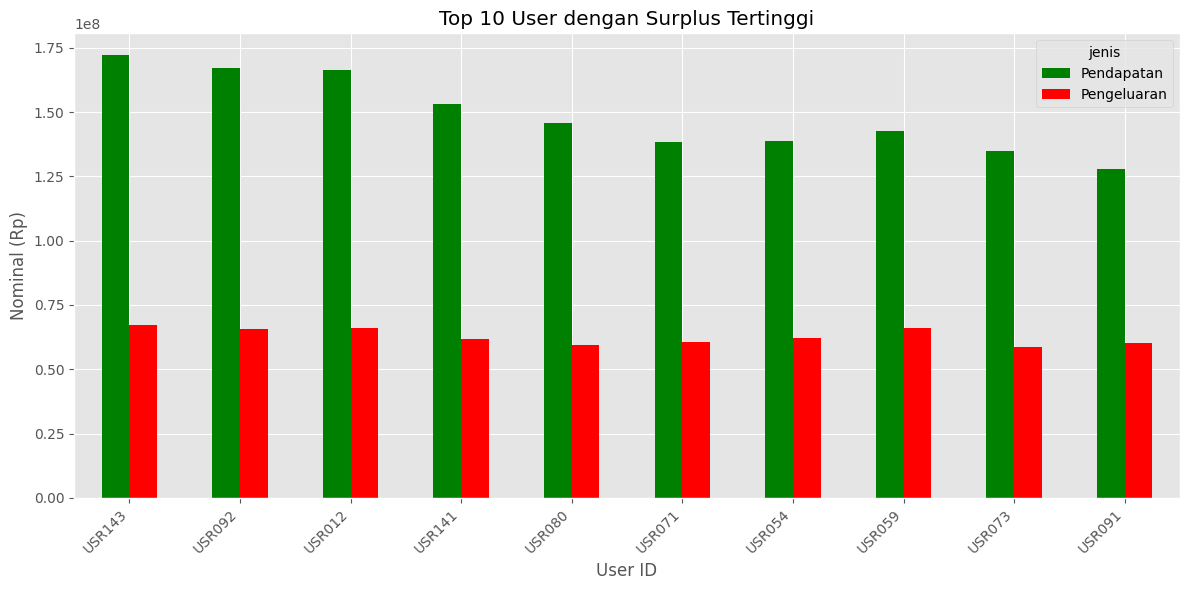

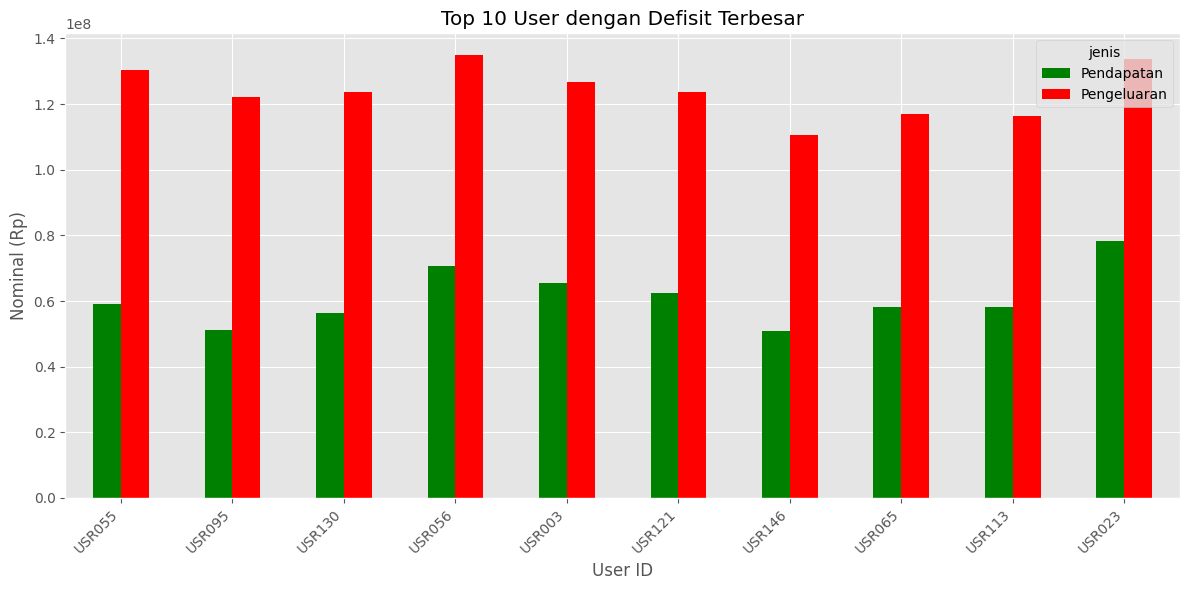

In [299]:
# Analisis perbandingan pendapatan vs pengeluaran per user

cashflow_by_user = df.groupby(['user_id', 'jenis'])['jumlah'].sum().unstack()

# Menghitung selisih pendapatan dan pengeluaran
cashflow_by_user['selisih'] = (
    cashflow_by_user.get('Pendapatan', 0)
    - cashflow_by_user.get('Pengeluaran', 0)
)

# Mengurutkan berdasarkan selisih terbesar
cashflow_by_user_sorted = cashflow_by_user.sort_values(
    'selisih',
    ascending=False
)

print("Perbandingan Pendapatan vs Pengeluaran per User:")
print(cashflow_by_user_sorted.head(10))


# Visualisasi Top 10 User dengan Surplus Tertinggi
top_surplus = cashflow_by_user.sort_values(
    'selisih',
    ascending=False
).head(10)

fig, ax = plt.subplots(figsize=(12,6))

top_surplus[['Pendapatan', 'Pengeluaran']].plot(
    kind='bar',
    ax=ax,
    color=['green', 'red']
)

ax.set_title('Top 10 User dengan Surplus Tertinggi')
ax.set_ylabel('Nominal (Rp)')
ax.set_xlabel('User ID')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


# Visualisasi Top 10 User dengan Defisit Terbesar
top_defisit = cashflow_by_user.sort_values(
    'selisih'
).head(10)

fig, ax = plt.subplots(figsize=(12,6))

top_defisit[['Pendapatan', 'Pengeluaran']].plot(
    kind='bar',
    ax=ax,
    color=['green', 'red']
)

ax.set_title('Top 10 User dengan Defisit Terbesar')
ax.set_ylabel('Nominal (Rp)')
ax.set_xlabel('User ID')

plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Berdasarkan hasil analisis per user, beberapa pengguna memiliki kondisi cash flow positif dengan selisih pendapatan yang jauh lebih tinggi dibanding pengeluaran.

User **USR143** memiliki surplus tertinggi sekitar **Rp104 juta**, diikuti oleh **USR092** sebesar **Rp101 juta** dan **USR012** sebesar **Rp100 juta**.

Hasil ini menunjukkan bahwa terdapat perbedaan kondisi cash flow antar pengguna, terutama pada kemampuan menjaga keseimbangan antara pendapatan dan pengeluaran.

In [300]:
# Hitung jumlah user surplus dan defisit

total_user = len(cashflow_by_user)

user_surplus = (cashflow_by_user['selisih'] > 0).sum()
user_defisit = (cashflow_by_user['selisih'] < 0).sum()

persen_surplus = (user_surplus / total_user) * 100
persen_defisit = (user_defisit / total_user) * 100

print(f"Total User           : {total_user}")
print(f"User Surplus         : {user_surplus} ({persen_surplus:.2f}%)")
print(f"User Defisit         : {user_defisit} ({persen_defisit:.2f}%)")

Total User           : 150
User Surplus         : 88 (58.67%)
User Defisit         : 62 (41.33%)


Berdasarkan hasil analisis per user, sebanyak **88 pengguna (58,67%)** memiliki kondisi cash flow positif karena pendapatan lebih besar dibanding pengeluaran. Sementara itu, **62 pengguna (41,33%)** mengalami defisit dengan total pengeluaran yang melebihi pendapatan.

Hasil ini menunjukkan bahwa sebagian besar pengguna masih memiliki kondisi cash flow yang relatif positif, meskipun terdapat cukup banyak pengguna dengan tingkat pengeluaran yang lebih tinggi dibanding pemasukan mereka.

# Pertanyaan Bisnis 5
## Metode Pembayaran yang Paling Sering Digunakan

In [301]:
payment_method = df['metode_pembayaran'].value_counts()

payment_method

metode_pembayaran
Transfer    26338
Debit       23690
Cash        23576
E-Wallet    23563
QRIS        23429
Unknown       612
Name: count, dtype: int64

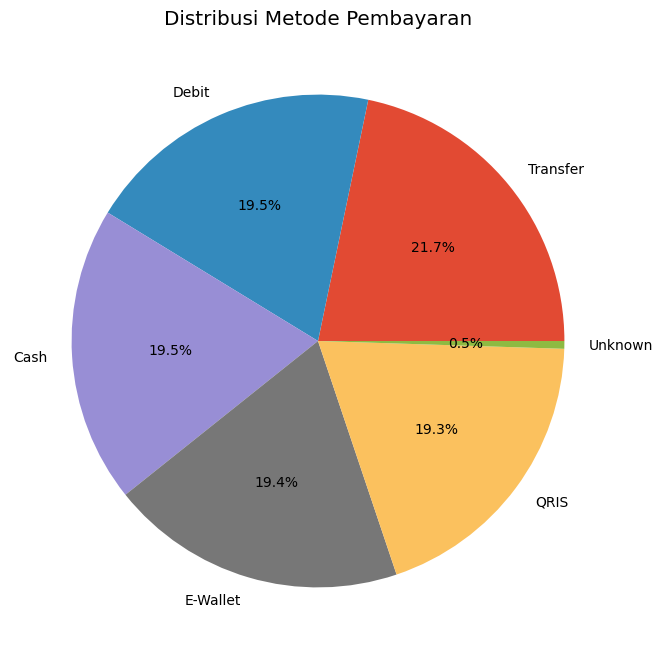

In [302]:
## Visualisasi Metode Pembayaran
plt.figure(figsize=(8,8))

plt.pie(
    payment_method.values,
    labels=payment_method.index,
    autopct='%1.1f%%'
)

plt.title('Distribusi Metode Pembayaran')

plt.show()

Berdasarkan hasil analisis, metode pembayaran **Transfer** memiliki jumlah transaksi tertinggi dengan total **26.338 transaksi**. Namun, jumlah transaksi pada metode pembayaran lain seperti **Debit**, **Cash**, **E-Wallet**, dan **QRIS** tidak berbeda jauh, sehingga distribusi penggunaan metode pembayaran cenderung relatif merata.

Hasil ini menunjukkan bahwa pengguna menggunakan kombinasi metode pembayaran digital maupun konvensional dalam aktivitas transaksi sehari-hari.

Selain itu, terdapat **612 transaksi** dengan metode pembayaran `Unknown`, yang berasal dari proses penanganan missing value pada tahap data cleaning.

# Pertanyaan Bisnis 6
## Distribusi Transaksi Berdasarkan Kota

In [303]:
lokasi_transaksi = df['lokasi'].value_counts()

lokasi_transaksi

lokasi
Surabaya      30396
Bandung       27701
Yogyakarta    23606
Jakarta       20360
Semarang      19145
Name: count, dtype: int64

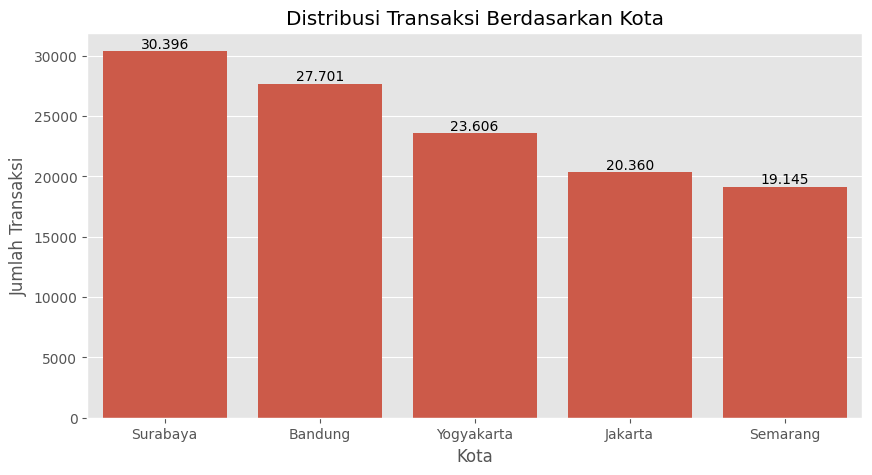

In [304]:
plt.figure(figsize=(10,5))

ax = sns.barplot(
    x=lokasi_transaksi.index,
    y=lokasi_transaksi.values
)

# tambah angka
for i, value in enumerate(lokasi_transaksi.values):
    ax.text(
        i,
        value,
        f'{value:,}'.replace(',', '.'),
        ha='center',
        va='bottom'
    )

plt.title('Distribusi Transaksi Berdasarkan Kota')
plt.xlabel('Kota')
plt.ylabel('Jumlah Transaksi')

plt.show()

Berdasarkan hasil analisis, kota **Surabaya** memiliki jumlah transaksi tertinggi dengan total **30.396 transaksi**, diikuti oleh **Bandung** sebanyak **27.701 transaksi** dan **Yogyakarta** sebanyak **23.606 transaksi**.

Sementara itu, **Jakarta** dan **Semarang** memiliki jumlah transaksi yang relatif lebih rendah dibanding kota lainnya.

Distribusi transaksi yang tersebar di beberapa kota menunjukkan bahwa aktivitas transaksi pengguna tidak terpusat pada satu wilayah tertentu. Perbedaan jumlah transaksi antar kota juga dapat menjadi pertimbangan dalam menentukan prioritas pengembangan layanan maupun strategi pemasaran fintech.

# Pertanyaan Bisnis 7
## Apakah terdapat transaksi abnormal atau anomali pada data transaksi pengguna?

In [305]:
Q1 = df['jumlah'].quantile(0.25)
Q3 = df['jumlah'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier = df[
    (df['jumlah'] < lower_bound) |
    (df['jumlah'] > upper_bound)
]

outlier.head()

,user_id,profil_user,tanggal,merchant,kategori,jumlah,jenis,metode_pembayaran,lokasi
2,USR021,Pekerja Kantoran,2025-03-02,IndiHome,Tagihan,273844,Pengeluaran,Transfer,Semarang
14,USR098,Gamer,2026-04-02,PLN,Tagihan,774077,Pengeluaran,Cash,Bandung
23,USR015,Gamer,2025-05-01,Gaji Bulanan,Pendapatan,8931505,Pendapatan,Transfer,Bandung
24,USR006,Gamer,2026-01-18,THR,Pendapatan,1500000,Pendapatan,Transfer,Yogyakarta
28,USR108,Gamer,2025-06-28,IndiHome,Tagihan,452344,Pengeluaran,Transfer,Yogyakarta


In [306]:
len(outlier)

15915

Berdasarkan metode **Interquartile Range (IQR)**, ditemukan sebanyak **15.915 transaksi outlier**.

Beberapa outlier ditemukan pada kategori Belanja, Tagihan, maupun Pendapatan dengan nominal transaksi yang relatif tinggi dibanding mayoritas data lainnya.

Jumlah outlier yang cukup besar menunjukkan bahwa data transaksi memiliki variasi nominal yang tinggi dan distribusi yang cenderung tidak normal (*right-skewed*). Kondisi ini umum ditemukan pada data finansial karena terdapat transaksi bernilai besar seperti gaji, bonus, maupun pembayaran tagihan tertentu.

# Save Clean Dataset

In [307]:
df.to_csv(
    '../data/processed/dataset_fintech_clean.csv',
    index=False
)

In [308]:
df_check = pd.read_csv('../data/processed/dataset_fintech_clean.csv')

print(df_check.shape)

(121208, 9)


# Final Check

In [309]:
print(df.head())
print(df.info())
print(df.shape)

  user_id       profil_user    tanggal     merchant kategori  jumlah  \
0  USR008   Mahasiswa Hemat 2025-10-25     IndiHome  Tagihan  155525   
1  USR072        Freelancer 2025-11-21    Telkomsel  Tagihan   67116   
2  USR021  Pekerja Kantoran 2025-03-02     IndiHome  Tagihan  273844   
3  USR065   Mahasiswa Boros 2025-07-22  Ayam Geprek  Makanan   20208   
4  USR010        Freelancer 2025-06-16       Uniqlo  Belanja  165598   

         jenis metode_pembayaran      lokasi  
0  Pengeluaran              QRIS    Semarang  
1  Pengeluaran          E-Wallet     Bandung  
2  Pengeluaran          Transfer    Semarang  
3  Pengeluaran              QRIS  Yogyakarta  
4  Pengeluaran          Transfer    Semarang  
<class 'pandas.core.frame.DataFrame'>
Index: 121208 entries, 0 to 122389
Data columns (total 9 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   user_id            121208 non-null  object        
 1   profil_

#### Final Check Dataset

Setelah seluruh proses preprocessing dan data cleaning dilakukan, dataset akhir memiliki **121.208 baris** dan **9 kolom**.

Beberapa tahapan preprocessing yang telah dilakukan meliputi:
- Penanganan missing value pada kolom `merchant` dan `metode_pembayaran`
- Penghapusan data duplikat
- Konversi tipe data kolom `tanggal` menjadi format `datetime`
- Pemeriksaan konsistensi struktur dan tipe data

Struktur dataset akhir terdiri dari:
- 1 kolom numerik (`jumlah`)
- 1 kolom datetime (`tanggal`)
- 7 kolom kategorikal (`object`)

Secara keseluruhan, dataset telah bersih, konsisten, dan siap digunakan untuk proses eksplorasi data, visualisasi, maupun analisis lebih lanjut.

---

### Data Dictionary

| Kolom | Tipe Data | Deskripsi |
|---|---|---|
| `user_id` | object | ID unik untuk setiap pengguna. |
| `profil_user` | object | Profil atau karakteristik perilaku pengguna. |
| `tanggal` | datetime | Tanggal terjadinya transaksi. |
| `merchant` | object | Nama merchant atau penyedia layanan tempat transaksi dilakukan. |
| `kategori` | object | Kategori transaksi, seperti Belanja, Makanan, dan Tagihan. |
| `jumlah` | int64 | Nominal transaksi dalam Rupiah (Rp). |
| `jenis` | object | Jenis transaksi, terdiri dari Pendapatan dan Pengeluaran. |
| `metode_pembayaran` | object | Metode pembayaran yang digunakan pengguna saat transaksi. |
| `lokasi` | object | Kota atau lokasi terjadinya transaksi. |

## Kesimpulan Umum

Berdasarkan hasil analisis data transaksi pengguna fintech, diperoleh beberapa insight penting terkait perilaku transaksi pengguna.

1. **Kategori pengeluaran paling dominan** adalah **Belanja** dengan total transaksi sekitar **Rp4,46 miliar**, diikuti oleh kategori **Tagihan**, **Makanan**, **Transportasi**, dan **Hiburan**. Hal ini menunjukkan bahwa sebagian besar pengeluaran pengguna didominasi oleh aktivitas konsumsi dan kebutuhan rutin harian.

2. **Merchant yang paling sering digunakan** adalah **Grab** dengan total **4.800 transaksi**, disusul oleh Indomaret, Blue Bird, Gojek, dan KRL. Tingginya frekuensi transaksi pada merchant transportasi dan retail menunjukkan bahwa aktivitas pengguna banyak berkaitan dengan kebutuhan mobilitas dan belanja harian.

3. **Pola transaksi dari waktu ke waktu** menunjukkan tren yang fluktuatif dengan beberapa lonjakan transaksi pada periode tertentu. Hal ini mengindikasikan adanya perubahan aktivitas transaksi pengguna pada waktu-waktu tertentu.

4. **Perbandingan pendapatan dan pengeluaran** menunjukkan bahwa secara keseluruhan total pendapatan pengguna masih sedikit lebih tinggi dibanding pengeluaran. Namun, beberapa profil pengguna seperti **Mahasiswa Boros** dan **Gamer** mengalami defisit, sedangkan **Pekerja Kantoran** dan **Freelancer** memiliki kondisi cash flow yang lebih positif. Pada tingkat kota, Jakarta dan Semarang memiliki surplus, sementara Surabaya dan Yogyakarta mengalami defisit.

5. **Metode pembayaran yang paling sering digunakan** adalah **Transfer**, diikuti oleh Debit, Cash, E-Wallet, dan QRIS. Distribusi transaksi yang relatif merata pada berbagai metode pembayaran menunjukkan bahwa pengguna menggunakan kombinasi metode pembayaran digital maupun konvensional dalam aktivitas transaksi sehari-hari.

6. **Distribusi transaksi berdasarkan kota** menunjukkan bahwa **Surabaya** menjadi kota dengan jumlah transaksi tertinggi, diikuti oleh Bandung dan Yogyakarta. Aktivitas transaksi yang tersebar di beberapa kota besar menunjukkan penggunaan layanan finansial digital yang cukup merata.

7. Berdasarkan metode **Interquartile Range (IQR)**, ditemukan sebanyak **15.824 transaksi outlier**. Beberapa outlier ditemukan pada kategori Belanja, Tagihan, maupun Pendapatan dengan nominal transaksi yang relatif tinggi dibanding mayoritas data lainnya. Kondisi ini menunjukkan bahwa data transaksi memiliki variasi nominal yang cukup besar dan distribusi yang cenderung tidak normal (*right-skewed*).

**Kesimpulan akhir:**  
Secara umum, hasil analisis menunjukkan bahwa aktivitas transaksi pengguna didominasi oleh kebutuhan konsumsi dan pembayaran rutin harian dengan penggunaan metode pembayaran yang cukup beragam. Selain itu, ditemukan adanya perbedaan perilaku finansial antar profil pengguna maupun wilayah transaksi, terutama pada kondisi cash flow dan intensitas transaksi pengguna.

Hasil analisis ini dapat dimanfaatkan sebagai dasar dalam pengembangan layanan fintech, segmentasi pengguna, personalisasi promosi, serta monitoring pola transaksi pengguna untuk mendukung pengambilan keputusan berbasis data.